# 1 Import libraries & data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# pd.read_parquet('data/yellow_tripdata_2019-01.parquet')
taxi_jan_data = pd.read_csv('data/yellow_tripdata_2019-01.csv')
taxi_data = pd.concat([taxi_jan_data])

In [2]:
print(taxi_data.shape)
taxi_data.head()

(7667792, 18)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1,1.5,1,N,151,239,1,7.0,0.5,0.5,1.65,0.0,0.3,9.95,NaN
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1,2.6,1,N,239,246,1,14.0,0.5,0.5,1.00,0.0,0.3,16.30,NaN
2,2,2018-12-21 13:48:30,2018-12-21 13:52:40,3,0.0,1,N,236,236,1,4.5,0.5,0.5,0.00,0.0,0.3,5.80,NaN
3,2,2018-11-28 15:52:25,2018-11-28 15:55:45,5,0.0,1,N,193,193,2,3.5,0.5,0.5,0.00,0.0,0.3,7.55,NaN
4,2,2018-11-28 15:56:57,2018-11-28 15:58:33,5,0.0,2,N,193,193,2,52.0,0.0,0.5,0.00,0.0,0.3,55.55,NaN


# 2 Data exploration

In [3]:
taxi_data.info()
taxi_data.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7667792 entries, 0 to 7667791
Data columns (total 18 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        int64  
 4   trip_distance          float64
 5   RatecodeID             int64  
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           int64  
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
dtypes: float64(9), int64(6), object(3)
memory usage: 1.0+ GB


,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
count,7667792.00,7667792.00,7667792.00,7667792.00,7667792.00,7667792.00,7667792.00,7667792.00,7667792.00,7667792.00,7667792.00,7667792.00,7667792.00,7667792.00,2811814.00
mean,1.64,1.57,2.80,1.06,165.50,163.75,1.29,12.41,0.33,0.50,1.83,0.32,0.30,15.68,0.00
std,0.54,1.22,3.74,0.68,66.39,70.36,0.47,262.07,0.51,0.05,2.50,2.02,0.02,262.29,0.01
min,1.00,0.00,0.00,1.00,1.00,1.00,1.00,-362.00,-60.00,-0.50,-63.50,-70.00,-0.30,-362.80,0.00
25%,1.00,1.00,0.90,1.00,130.00,113.00,1.00,6.00,0.00,0.50,0.00,0.00,0.30,8.19,0.00
50%,2.00,1.00,1.53,1.00,162.00,162.00,1.00,8.50,0.00,0.50,1.43,0.00,0.30,11.27,0.00
75%,2.00,2.00,2.80,1.00,234.00,234.00,2.00,13.50,0.50,0.50,2.33,0.00,0.30,16.56,0.00
max,4.00,9.00,831.80,99.00,265.00,265.00,4.00,623259.86,535.38,60.80,787.25,3288.00,0.60,623261.66,2.50


In [4]:
taxi_data.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge'],
      dtype='object')

In [5]:
taxi_data = taxi_data[['tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID',
       'PULocationID', 'DOLocationID', 'payment_type', 'total_amount']]

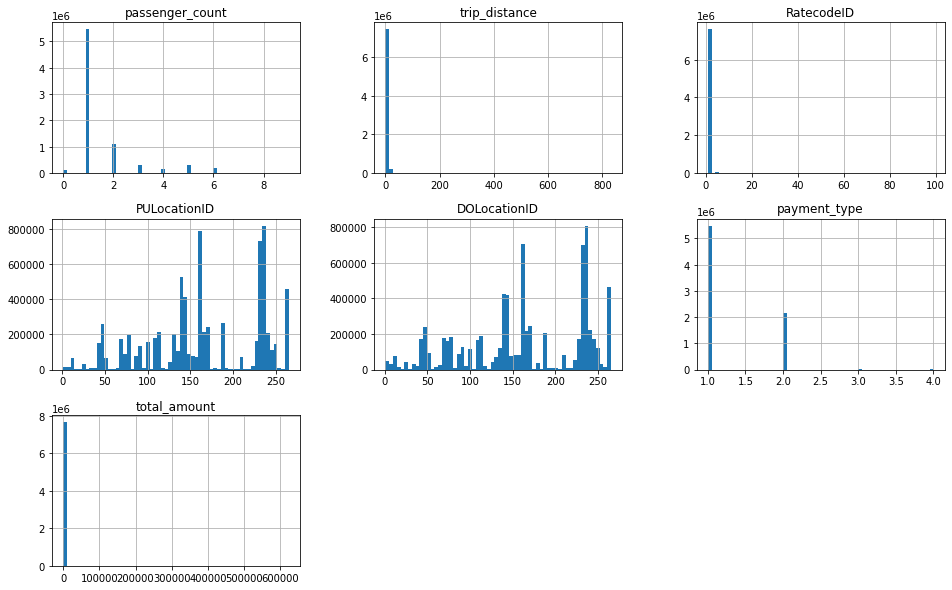

In [6]:
taxi_data.hist(figsize=(16, 10), bins=60)
plt.show()

In [7]:
taxi_data['RatecodeID'].value_counts()

RatecodeID
1     7430139
2      166090
5       54569
3       11801
4        4895
99        252
6          46
Name: count, dtype: int64

In [8]:
taxi_data['trip_distance'].describe().round(2)

count    7667792.00
mean           2.80
std            3.74
min            0.00
25%            0.90
50%            1.53
75%            2.80
max          831.80
Name: trip_distance, dtype: float64

<Axes: xlabel='index', ylabel='total_amount'>

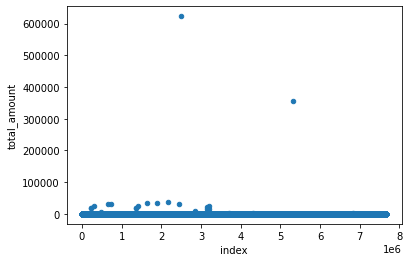

In [9]:
taxi_data.reset_index().plot(kind='scatter', x='index', y='total_amount')

<Axes: xlabel='index', ylabel='total_amount'>

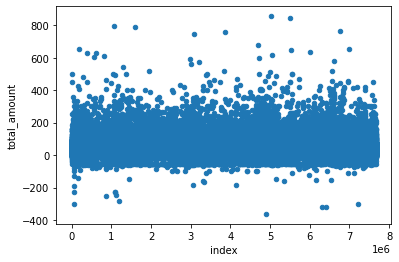

In [10]:
taxi_data[taxi_data['total_amount'] < 1000].reset_index().plot(x='index', y='total_amount', kind= 'scatter')

### The two things to deal with: negative values and very high values. Let's first look at negative values.

(7131, 9)


<Axes: xlabel='index', ylabel='total_amount'>

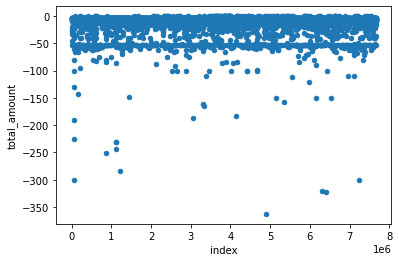

In [11]:
print(taxi_data[taxi_data['total_amount'] < 0].shape)
taxi_data[taxi_data['total_amount'] < 0].reset_index().plot(x='index', y='total_amount', kind='scatter')

In [12]:
taxi_data[taxi_data['total_amount'] < 0].head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
663,2019-01-01 00:32:56,2019-01-01 00:33:35,2,0.10,1,148,148,3,-3.8
2402,2019-01-01 00:14:18,2019-01-01 00:40:55,1,4.13,1,170,238,4,-20.3
2541,2019-01-01 00:31:27,2019-01-01 00:42:39,1,1.35,1,162,234,4,-9.8
2544,2019-01-01 00:45:57,2019-01-01 00:46:07,1,0.00,1,234,234,4,-3.8
2547,2019-01-01 00:48:35,2019-01-01 00:49:59,1,0.16,1,234,234,4,-4.3


In [13]:
taxi_data[taxi_data['total_amount'] < 0]['payment_type'].value_counts()

payment_type
3    4088
4    2666
2     376
1       1
Name: count, dtype: int64

In [14]:
import warnings
warnings.filterwarnings('ignore')

# convert object Series to datetime Series
taxi_0 = taxi_data[taxi_data['total_amount'] < 0]

taxi_0['tpep_pickup_datetime'] = pd.to_datetime(taxi_0['tpep_pickup_datetime'])
taxi_0['tpep_dropoff_datetime'] = pd.to_datetime(taxi_0['tpep_dropoff_datetime'])

delta = taxi_0['tpep_dropoff_datetime'] - taxi_0['tpep_pickup_datetime']
delta.agg(['min', 'max'])

min   0 days 00:00:00
max   0 days 23:57:40
dtype: timedelta64[ns]

<Axes: >

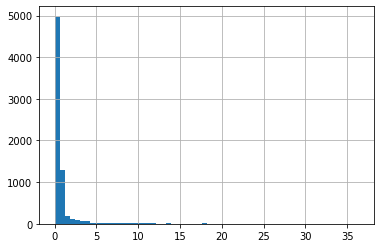

In [15]:
taxi_data[taxi_data['total_amount'] < 0]['trip_distance'].hist(bins=60)

In [16]:
print(taxi_data[taxi_data['total_amount'] == 0].shape)
taxi_data[taxi_data['total_amount'] == 0].head()

(1414, 9)


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
3552,2019-01-01 00:18:46,2019-01-01 00:18:46,1,0.0,5,186,264,2,0.0
9138,2019-01-01 00:41:47,2019-01-01 00:41:47,1,0.0,5,246,264,2,0.0
13256,2019-01-01 00:19:38,2019-01-01 00:20:35,1,0.0,1,193,193,1,0.0
13257,2019-01-01 00:43:34,2019-01-01 00:43:34,1,0.0,1,7,7,2,0.0
13258,2019-01-01 00:02:52,2019-01-01 00:02:52,1,0.0,1,264,7,2,0.0


In [17]:
taxi_data[taxi_data['total_amount'] == 0]['payment_type'].value_counts()

payment_type
1    815
2    569
3     29
4      1
Name: count, dtype: int64

<Axes: >

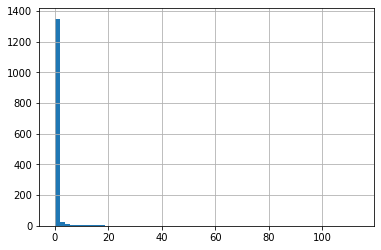

In [18]:
taxi_data[taxi_data['total_amount'] == 0]['trip_distance'].hist(bins=60)

In [19]:
taxi_data[taxi_data['total_amount'] == 0]['trip_distance'].value_counts()

trip_distance
0.00     1270
1.00        4
0.02        4
0.01        4
0.10        3
         ... 
0.59        1
10.84       1
2.91        1
1.20        1
0.53        1
Name: count, Length: 110, dtype: int64

<Axes: xlabel='index', ylabel='total_amount'>

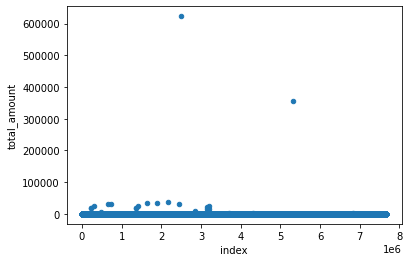

In [20]:
taxi_data.reset_index().plot(x='index', y='total_amount', kind='scatter')

In [21]:
taxi_data[taxi_data['total_amount'] > 200].shape

(1166, 9)

In [22]:
taxi_data['total_amount'].mean()

15.68222215991253

### We can agree to cut from 200$ level

# 3 Cleaning data

In [23]:
taxi_data.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
0,2019-01-01 00:46:40,2019-01-01 00:53:20,1,1.5,1,151,239,1,9.95
1,2019-01-01 00:59:47,2019-01-01 01:18:59,1,2.6,1,239,246,1,16.30
2,2018-12-21 13:48:30,2018-12-21 13:52:40,3,0.0,1,236,236,1,5.80
3,2018-11-28 15:52:25,2018-11-28 15:55:45,5,0.0,1,193,193,2,7.55
4,2018-11-28 15:56:57,2018-11-28 15:58:33,5,0.0,2,193,193,2,55.55


In [24]:
print(taxi_data.shape)
taxi_data[
    (taxi_data['total_amount'] <= 0) | 
    (taxi_data['total_amount'] > 200)
    ].shape

(7667792, 9)


(9711, 9)

In [25]:
index_to_drop = taxi_data[
    (taxi_data['total_amount'] <= 0) | 
    (taxi_data['total_amount'] > 200)
    ].index

taxi_data.drop(index_to_drop, axis=0).shape
taxi_data.drop(index=index_to_drop).shape

(7658081, 9)

In [26]:
taxi_data_filtered = taxi_data[(taxi_data['total_amount'] >= 0) & (taxi_data['total_amount'] < 200)]
print(taxi_data_filtered.shape)
taxi_data.shape

(7659490, 9)


(7667792, 9)

### Checking for missing values

In [27]:
taxi_data_filtered.isna().sum()

tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
total_amount             0
dtype: int64

# 4 Data preparation

In [28]:
taxi_data_prepared = taxi_data_filtered.copy()

Making sure everything is in the right type

In [29]:
# print(taxi_data_prepared.dtypes)
taxi_data_prepared['tpep_pickup_datetime'] = pd.to_datetime(taxi_data_prepared['tpep_pickup_datetime'])
taxi_data_prepared['tpep_dropoff_datetime'] = pd.to_datetime(taxi_data_prepared['tpep_dropoff_datetime'])

print(taxi_data_prepared.dtypes)

tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                   int64
trip_distance                   float64
RatecodeID                        int64
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
total_amount                    float64
dtype: object


In [30]:
taxi_data_prepared['RatecodeID'] = taxi_data_prepared['RatecodeID'].astype('str')
taxi_data_prepared['PULocationID'] = taxi_data_prepared['PULocationID'].astype('str')
taxi_data_prepared['DOLocationID'] = taxi_data_prepared['DOLocationID'].astype('str')
taxi_data_prepared['payment_type'] = taxi_data_prepared['payment_type'].astype('str')

taxi_data_prepared.dtypes

tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                   int64
trip_distance                   float64
RatecodeID                       object
PULocationID                     object
DOLocationID                     object
payment_type                     object
total_amount                    float64
dtype: object

In [31]:
taxi_data_prepared['payment_type'].value_counts()

payment_type
1    5485085
2    2136849
3      29069
4       8487
Name: count, dtype: int64

In [32]:
taxi_data_prepared['transaction_date'] = pd.to_datetime(taxi_data_prepared['tpep_pickup_datetime']).dt.date
taxi_data_prepared['transaction_year'] = pd.to_datetime(taxi_data_prepared['tpep_pickup_datetime']).dt.year
taxi_data_prepared['transaction_month'] = pd.to_datetime(taxi_data_prepared['tpep_pickup_datetime']).dt.month
taxi_data_prepared['transaction_day'] = pd.to_datetime(taxi_data_prepared['tpep_pickup_datetime']).dt.day
taxi_data_prepared['transaction_hour'] = pd.to_datetime(taxi_data_prepared['tpep_pickup_datetime']).dt.hour

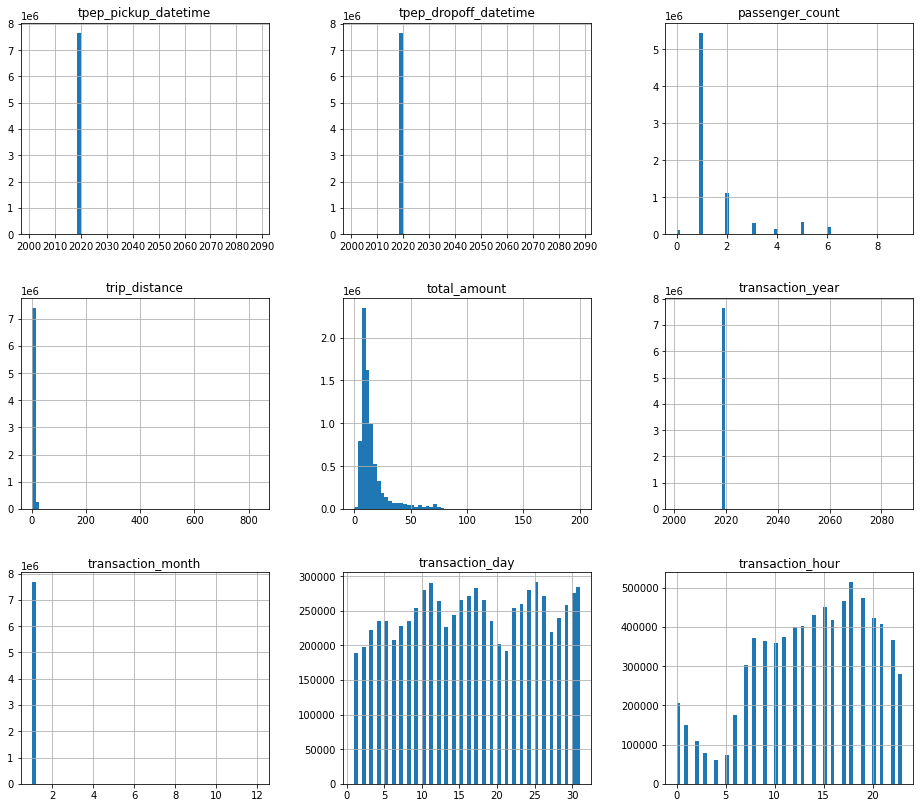

In [33]:
taxi_data_prepared.hist(bins=60, figsize=(16, 14))
plt.show()

In [50]:
print(taxi_data_prepared[taxi_data_prepared['transaction_year'] != 2019].shape)
print(taxi_data_prepared[taxi_data_prepared['transaction_month'] != 1].shape)

taxi_data_prepared = taxi_data_prepared[taxi_data_prepared['transaction_year'] == 2019]
taxi_data_prepared = taxi_data_prepared[taxi_data_prepared['transaction_month'] == 1]

(0, 14)
(0, 14)


KeyboardInterrupt: 

Noting down categorical and numerical columns

In [ ]:
categorical_cols = ['PULocationID', 'transaction_date', 'transaction_month', 'transaction_day', 'transaction_hour']
numerical_cols = ['trip_distance', 'total_amount']
all_needed_cols = categorical_cols + numerical_cols

In [ ]:
main_taxi_df = taxi_data_prepared[all_needed_cols]
print(main_taxi_df.shape)
main_taxi_df.head()

(7658954, 7)


,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount
0,151,2019-01-01,1,1,0,1.5,9.95
1,239,2019-01-01,1,1,0,2.6,16.30
7,163,2019-01-01,1,1,0,1.3,9.05
8,229,2019-01-01,1,1,0,3.7,18.50
9,141,2019-01-01,1,1,0,2.1,13.00


Aggregate data points.
Now it is a good time to think about what we want to predict. 
Depending on this we need to transform our data to have a certain format.

In [ ]:
taxi_grouped_by_region = main_taxi_df.groupby(categorical_cols).mean().reset_index()
taxi_grouped_by_region['count_of_transactions'] = main_taxi_df.groupby(categorical_cols).count().reset_index()['total_amount']
print(taxi_grouped_by_region.shape)
taxi_grouped_by_region.head()

(102556, 8)


,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions
0,1,2019-01-01,1,1,2,0.0,21.800,1
1,1,2019-01-01,1,1,5,0.0,87.300,1
2,1,2019-01-01,1,1,6,0.0,80.300,1
3,1,2019-01-01,1,1,8,0.0,128.580,2
4,1,2019-01-01,1,1,10,16.9,43.245,4


<Axes: >

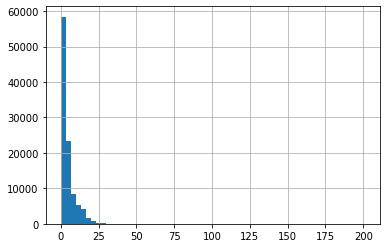

In [ ]:
taxi_grouped_by_region['trip_distance'].hist(bins=60, figsize=(6, 4))

<Axes: >

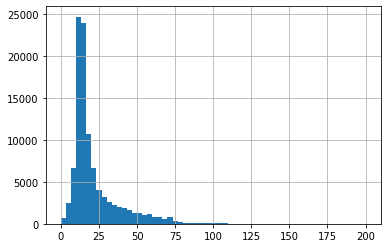

In [ ]:
taxi_grouped_by_region['total_amount'].hist(bins=60, figsize=(6, 4))

# 5 Benchmark model

In [34]:
# start coding from here - load grouped data file size 

import pandas as pd
import matplotlib.pyplot as plt

taxi_grouped_by_region = pd.read_csv('data/taxi_grouped.csv')
taxi_grouped_by_region = taxi_grouped_by_region.drop(labels='Unnamed: 0', axis=1)

In [35]:
print(taxi_grouped_by_region[['transaction_date', 'transaction_month', 'transaction_day', 'transaction_hour']].dtypes)
data_for_benchmark_model = taxi_grouped_by_region.copy()

transaction_date     object
transaction_month     int64
transaction_day       int64
transaction_hour      int64
dtype: object


In [36]:
categorical_features_benchmark = ['PULocationID', 'transaction_month', 'transaction_day', 'transaction_hour']
input_features_benchmark = categorical_features_benchmark + ['trip_distance']
target_features_benchmark = ['total_amount']

## 5.1. Train-test split

In [37]:
from sklearn.model_selection import train_test_split

X_bench = data_for_benchmark_model[input_features_benchmark]
y_bench = data_for_benchmark_model[target_features_benchmark]
X_bench.dtypes

# one-hot encode
X_bench = pd.get_dummies(X_bench)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bench, y_bench, test_size=0.33, random_state=42)

## 5.2. Fit a model to the data

In [38]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=10)
tree.fit(X_train_b, y_train_b)

DecisionTreeRegressor(max_depth=10)

## 5.3. Model evaluation

In [39]:
model_at_hand = tree

y_pred_b = model_at_hand.predict(X_test_b)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from math import sqrt

print(f'Mean absolute errror: {mean_absolute_error(y_test_b, y_pred_b):.5f}')
print(f'Mean squared errror: {mean_squared_error(y_test_b, y_pred_b):.5f}')
print(f'Root mean squared errror: {sqrt(mean_squared_error(y_test_b, y_pred_b)):.5f}')
print(f'R2 score: {r2_score(y_test_b, y_pred_b):.5f}')

Mean absolute errror: 3.52860
Mean squared errror: 70.68616
Root mean squared errror: 8.40751
R2 score: 0.74775


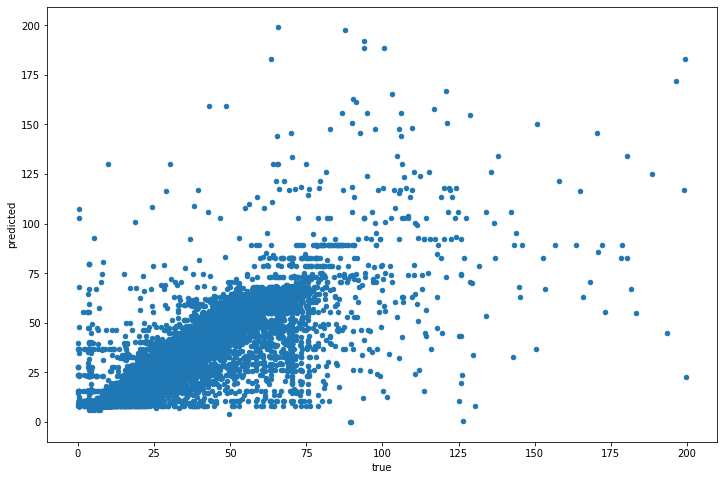

In [40]:
data = {'true': y_test_b.iloc[:, 0], 'predicted': y_pred_b}
# test: DataFrame - predicted: numpy array

results = pd.DataFrame(data)
results.plot(kind='scatter', x='true', y='predicted', figsize=(12, 8))
plt.show()

Could this be too good to be true?
Most likely there is a data leakage bacause 'trip_dstance' (input feat.) is correlated with (target feat.)'total_amount' 

## 5.4. Fix problems

Mean absolute errror: 8.40930
Mean squared errror: 189.80520
Root mean squared errror: 13.77698
R2 score: 0.32267


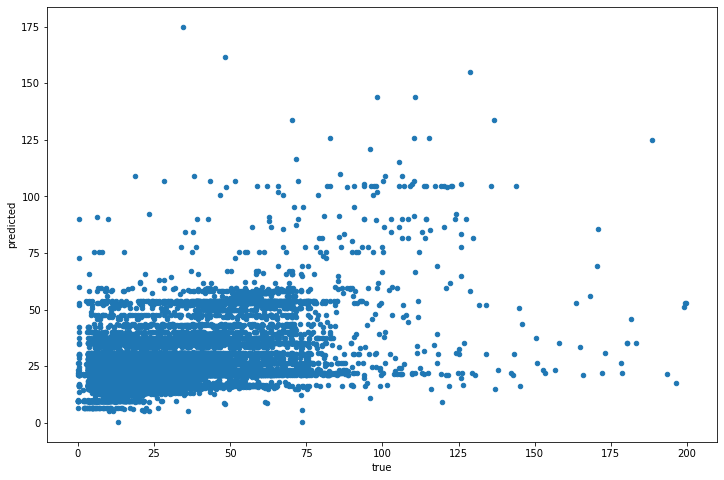

In [41]:
categorical_features_benchmark = ['PULocationID', 'transaction_month', 'transaction_day', 'transaction_hour']
input_features_benchmark = categorical_features_benchmark
target_features_benchmark = ['total_amount']

X_bench = data_for_benchmark_model[input_features_benchmark]
y_bench = data_for_benchmark_model[target_features_benchmark]
X_bench.dtypes

# one-hot encode
X_bench = pd.get_dummies(X_bench)

# split data
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bench, y_bench, test_size=0.33, random_state=42)

# fit a model
tree = DecisionTreeRegressor(max_depth=10)
tree.fit(X_train_b, y_train_b)

# model evaluation
model_at_hand = tree
y_pred_b = model_at_hand.predict(X_test_b)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from math import sqrt

print(f'Mean absolute errror: {mean_absolute_error(y_test_b, y_pred_b):.5f}')
print(f'Mean squared errror: {mean_squared_error(y_test_b, y_pred_b):.5f}')
print(f'Root mean squared errror: {sqrt(mean_squared_error(y_test_b, y_pred_b)):.5f}')
print(f'R2 score: {r2_score(y_test_b, y_pred_b):.5f}')

data = {'true': y_test_b.iloc[:, 0], 'predicted': y_pred_b}
# test: DataFrame - predicted: numpy array

results = pd.DataFrame(data)
results.plot(kind='scatter', x='true', y='predicted', figsize=(12, 8))
plt.show()

# 6 Data engineering

In [42]:
taxi_grouped_by_region.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions
0,1,2019-01-01,1,1,2,0.0,21.800,1
1,1,2019-01-01,1,1,5,0.0,87.300,1
2,1,2019-01-01,1,1,6,0.0,80.300,1
3,1,2019-01-01,1,1,8,0.0,128.580,2
4,1,2019-01-01,1,1,10,16.9,43.245,4


In [43]:
data_with_new_features = taxi_grouped_by_region.copy()

Date related features

In [44]:
data_with_new_features['transaction_date'] = pd.to_datetime(data_with_new_features['transaction_date'])
data_with_new_features['transaction_week_day'] = data_with_new_features['transaction_date'].dt.weekday

print(f'Here the week starts from 0 which is Monday')
print(data_with_new_features['transaction_week_day'].value_counts().index)
data_with_new_features['weekend'] = data_with_new_features['transaction_week_day'].apply(lambda x: True if x == 5 | x == 6 else False)

Here the week starts from 0 which is Monday
Index([2, 3, 1, 4, 0, 5, 6], dtype='int32', name='transaction_week_day')


In [45]:
from pandas.tseries.holiday import USFederalHolidayCalendar
cal = USFederalHolidayCalendar()
holidays = cal.holidays(start='2018', end='2020').date
data_with_new_features['is_holiday'] = data_with_new_features['transaction_date'].isin(holidays)
data_with_new_features.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday
0,1,2019-01-01,1,1,2,0.0,21.800,1,1,False,True
1,1,2019-01-01,1,1,5,0.0,87.300,1,1,False,True
2,1,2019-01-01,1,1,6,0.0,80.300,1,1,False,True
3,1,2019-01-01,1,1,8,0.0,128.580,2,1,False,True
4,1,2019-01-01,1,1,10,16.9,43.245,4,1,False,True


Borough information

In [46]:
zone_lookup = pd.read_csv('data/taxi_zone_lookup.csv')
zone_lookup = zone_lookup[['LocationID', 'Borough']]
# zone_lookup['LocationID'] = zone_lookup['LocationID'].astype(str)
zone_lookup.dtypes

LocationID     int64
Borough       object
dtype: object

In [47]:
data_with_new_features = data_with_new_features.merge(zone_lookup, left_on='PULocationID', right_on='LocationID', how='left')
data_with_new_features = data_with_new_features.drop(labels='LocationID', axis=1)
data_with_new_features.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday,Borough
0,1,2019-01-01,1,1,2,0.0,21.800,1,1,False,True,EWR
1,1,2019-01-01,1,1,5,0.0,87.300,1,1,False,True,EWR
2,1,2019-01-01,1,1,6,0.0,80.300,1,1,False,True,EWR
3,1,2019-01-01,1,1,8,0.0,128.580,2,1,False,True,EWR
4,1,2019-01-01,1,1,10,16.9,43.245,4,1,False,True,EWR


In [50]:
print(data_with_new_features.isna().sum())
data_with_new_features['Borough'].value_counts()

PULocationID               0
transaction_date           0
transaction_month          0
transaction_day            0
transaction_hour           0
trip_distance              0
total_amount               0
count_of_transactions      0
transaction_week_day       0
weekend                    0
is_holiday                 0
Borough                  709
dtype: int64


Borough
Manhattan        45309
Brooklyn         23633
Queens           22002
Bronx             9586
Unknown            744
Staten Island      302
EWR                271
Name: count, dtype: int64

Weather related features

In [ ]:
import requests
import pandas as pd

params = {
    'latitude': 40.7128,
    'longitude': -74.0060,
    'start_date': '2019-01-01',
    'end_date': '2019-01-31',
    'hourly': 'temperature_2m,relative_humidity_2m,cloudcover,windspeed_10m,precipitation',
    'timezone': 'America/New_York'
}

# API request for weather data between January 1, 2019 and January 31, 2019
response = requests.get('https://archive-api.open-meteo.com/v1/archive', params=params)

print(response.json().keys())
print(response.json()['hourly'].keys())

if response.status_code == 200:
    data = response.json()
    df = pd.DataFrame(data['hourly'])
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)

    df_3h = df.resample('3H').agg({
        'temperature_2m': 'mean',
        'relative_humidity_2m': 'mean',
        'cloudcover': 'mean',
        'windspeed_10m': 'mean',
        'precipitation': 'sum'
    })

    df_3h.to_csv('data/nyc_weather_jan2019_3h.csv')
    print("Data saved in the file: 'nyc_weather_jan2019_3h.csv'. Status code: {response.status_code}")
else:
    print(f"Error occured when transfering data - status code: {response.status_code}")


df_3h.head()

In [ ]:
index = pd.date_range('1/1/2000', periods=9, freq='H')
series = pd.Series(range(9), index=index)
print(series)

series.resample('3H').agg('sum')

In [1]:
pd.read_csv('data/nyc_weather_jan2019_3h.csv')

NameError: name 'pd' is not defined